In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

d = {i:f[i][:] for i in f.keys()}
data= pd.DataFrame(data=d)


In [50]:
from sklearn.model_selection import train_test_split
Data, Data_residual = train_test_split(data, test_size=0.99, random_state=42)
#reduce data for a quick try 
Data

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
4024373,0.374112,-0.411320,0.667187,0.429477,0.166942,0.026046,-0.815423,0,1.579100,727.589645,0.327597,0.564368,0.464752,0.665594,3.097083
10266942,-0.386719,-0.107437,0.050577,-0.636361,0.119321,-0.079218,-0.751228,0,2.412216,978.876283,2.141414,0.229324,1.481204,0.951344,2.638567
6459144,0.222820,0.410252,0.129998,-0.491348,0.226931,-0.469758,-0.532657,1,3.054480,455.438278,2.793137,0.483263,-0.977696,12.457424,1.022583
7925187,0.116683,-0.031429,0.452670,0.041270,0.070549,-0.020347,-0.121303,0,0.757432,517.901504,2.588458,0.442071,0.495163,3.051620,3.461062
13478872,-0.185203,-0.504794,-0.094734,0.525282,0.024376,-0.110316,0.306694,0,1.863686,568.899711,2.544463,0.292520,-1.012451,2.319825,1.884367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9628519,-0.062566,-0.029044,-0.017995,-0.296909,0.206497,-0.028876,0.789893,0,1.682702,665.461217,0.145841,0.768718,0.548155,3.799074,1.829292
14586186,-0.052249,0.059512,-0.002064,0.055484,0.047031,0.011591,-0.942926,0,0.585501,106.541777,1.000963,0.235072,-2.917979,1.575189,3.273150
2234489,-0.136730,-0.133525,0.060114,0.010801,0.420237,0.621963,-0.359265,0,1.686631,619.064894,1.089616,0.660576,1.569158,3.481899,0.883134
13315092,0.082348,0.315229,-0.754933,-0.286381,-0.112122,0.508187,0.102491,1,0.377916,949.752628,1.010241,0.402383,1.471530,18.733222,0.095327


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from astroML.utils import completeness_contamination

Dt = Data.drop(['det','snr'], axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(Dt, Data['det'],test_size=0.33, random_state=42)


In [96]:
classifiers = []
predictions = []
Ncolors = np.arange(1, Dt.shape[1] + 1)
depths = [10,8]  #two different depths 

for depth in depths:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = DecisionTreeClassifier(random_state=0, max_depth=depth,
                                     criterion='entropy')
        clf.fit(X_train.values[:, :nc], Y_train)
        y_pred = clf.predict(X_test.values[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, Y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [[9.45378151e-04 1.15546218e-03 2.31092437e-03 1.89075630e-03
  2.10084034e-03 2.73109244e-03 3.15126050e-03 7.24789916e-03
  4.30672269e-03 4.51680672e-03 1.08193277e-02 1.00840336e-02
  8.37605042e-01]
 [3.15126050e-04 2.10084034e-04 1.15546218e-03 1.36554622e-03
  1.57563025e-03 1.36554622e-03 1.47058824e-03 2.41596639e-03
  1.68067227e-03 1.78571429e-03 7.35294118e-04 6.30252101e-04
  8.48844538e-01]]
contamination [[0.83928571 0.80357143 0.83941606 0.875      0.87341772 0.85945946
  0.80519481 0.78504673 0.85512367 0.85273973 0.78085106 0.78571429
  0.12489025]
 [0.88       0.91666667 0.86746988 0.85227273 0.80519481 0.82894737
  0.82051282 0.80672269 0.88148148 0.88513514 0.89552239 0.91304348
  0.1419622 ]]


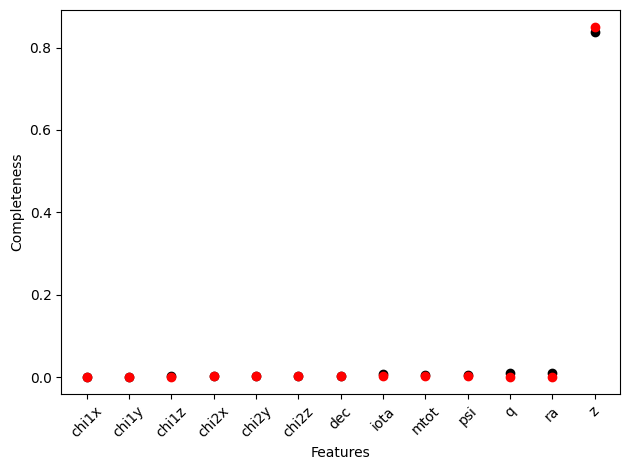

In [97]:
N_features=Dt.shape[1]

cols =list(Dt.columns.values)


for i in range(0,len(cols)):
    plt.scatter(i, completeness[0][i], color='black')
    plt.scatter(i, completeness[1][i], color='red')

plt.xticks(ticks=range(len(cols)), labels=cols, rotation=45)  # ruota le etichette se sono lunghe

plt.xlabel('Features')
plt.ylabel('Completeness')
plt.tight_layout()  # evita che le etichette escano fuori dal grafico
plt.show()



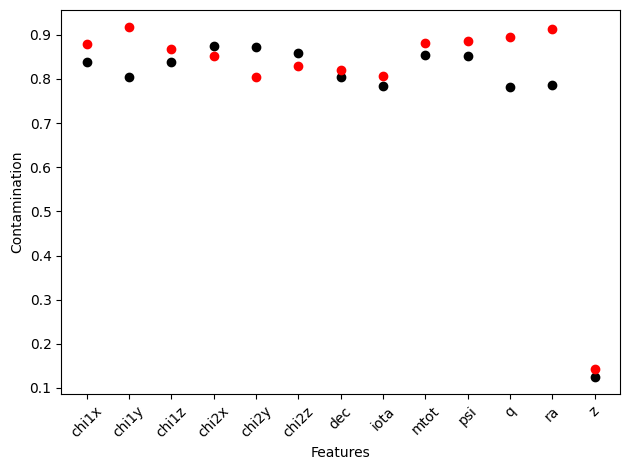

In [98]:
for i in range(0,len(cols)):
    plt.scatter(i, contamination[0][i], color='black')
    plt.scatter(i, contamination[1][i], color='red')

plt.xticks(ticks=range(len(cols)), labels=cols, rotation=45)  # ruota le etichette se sono lunghe

plt.xlabel('Features')
plt.ylabel('Contamination')
plt.tight_layout()  # evita che le etichette escano fuori dal grafico
plt.show()

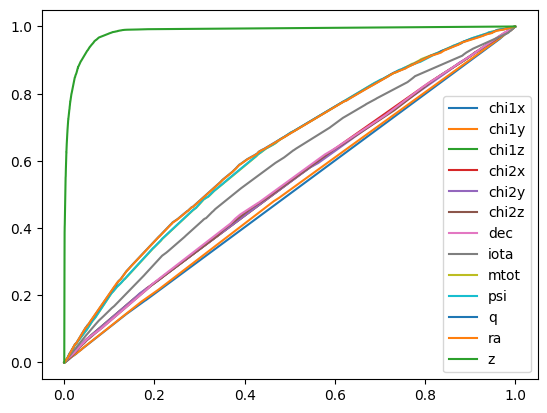

In [109]:
from sklearn.metrics import roc_curve

for i in range(len(cols)):

    clf.fit(X_train.values[:,0:i+1] ,Y_train )

    y_prob = clf.predict_proba(X_test.values[:,0:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(Y_test, y_prob)
    plt.plot(fpr, tpr, label=cols[i])
plt.legend()

#stai plottando solo l'ultimo dei due casi 

